In [1]:
import os
import torch
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import sys
sys.path.insert(0, '../../src')
import utils

# ── E_mix rejection table (replaces the log-linear approval test) ──
import yaml as _yaml
from rejection_mix import build_rejection_table_np as _build_rej_tbl_mix
with open('../../config/fiducial_mix.yaml') as _f_cfg_mix:
    _cfg_mix = _yaml.safe_load(_f_cfg_mix)
_REJ_TBL_GLOBAL = _build_rej_tbl_mix(
    (int(_cfg_mix['T']) + 1) * int(_cfg_mix['n_max']),
    float(_cfg_mix['kappa']), float(_cfg_mix['theta_b']),
)


In [2]:
# ── Configure ──────────────────────────────────────────────────────────────────
results_path = '../../outputs/fiducial_mix/mdp_output/sensitivity_results_mix.pt'
figures_dir  = '../../figures/fiducial_mix/sensitivity'
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs(figures_dir, exist_ok=True)

res = torch.load(results_path, weights_only=False)

rho_S_range      = np.array(res['rho_S_range'])       # (n_rho,)
theta_star_range = np.array(res['theta_star_range'])   # (n_theta,)
eps_star         = np.array(res['eps_star'])           # (n_rho,)
us_mdp           = np.array(res['us_mdp'])             # (n_rho,)
P_mdp            = np.array(res['P_mdp'])              # (n_rho,)
A_mdp            = np.array(res['A_mdp'])              # (n_rho,)
P_true           = np.array(res['P_true'])             # (n_rho, n_theta)
A_true           = np.array(res['A_true'])             # (n_rho, n_theta)
p_optout_true    = np.array(res['p_optout_true'])      # (n_rho, n_theta)
us_true          = np.array(res['us_true'])            # (n_rho, n_theta)
params           = res['params']

print('Parameters:')
for k, v in params.items():
    print(f'  {k}: {v}')
print(f'\nrho_S values  : {rho_S_range.tolist()}')
print(f'theta* values : {theta_star_range.tolist()}')

Parameters:
  rho_A: 240
  T: 3
  n_max: 200
  c0: 48.9
  c1: 0.066
  kappa: 0.05
  theta_b: 0.5
  alpha_0: 1.0
  beta_0: 1.0
  device: cuda
  action_stride: 1
  epsilon_max: 0.9
  tol: 1e-06
  n_episodes: 200000
  theta_fid: 0.65
  e_value: mixture_uniform

rho_S values  : [240.0, 500.0, 1000.0, 2000.0, 3000.0, 4000.0, 5000.0, 6000.0, 7000.0, 8000.0, 9000.0, 10000.0]
theta* values : [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.85, 0.9]


## 1. Optimal subsidy $\varepsilon^*$ vs $\rho_S$

For each value of the social utility of approval $\rho_S$, Algorithm 1 (divide-and-conquer) finds the subsidy $\varepsilon^*$ that maximises the principal's expected social utility $U^S = \rho_S P_{\text{approval}} - \varepsilon^* A$ under the MDP's Beta-Binomial dynamics.

Single-shot n_max = 800   rho_A = 240.0
   rho_S   rho_S/rho_A    eps*_fid     eps*_ss   n* (eps=0)    n* (eps=eps*_ss)
--------------------------------------------------------------------------------
   240.0         1.000      0.0272      0.0000       172.00              172.00
   500.0         2.083      0.0272      0.0597       172.00              188.00
  1000.0         4.167      0.0272      0.0597       172.00              188.00
  2000.0         8.333      0.0272      0.6224       172.00              267.00
  3000.0        12.500      0.3375      0.8942       172.00              296.00
  4000.0        16.667      0.3375      0.8942       172.00              296.00
  5000.0        20.833      0.7626      0.8942       172.00              296.00
  6000.0        25.000      0.7626      0.8942       172.00              296.00
  7000.0        29.167      0.7626      0.8942       172.00              296.00
  8000.0        33.333      0.7626      0.8942       172.00              296.00

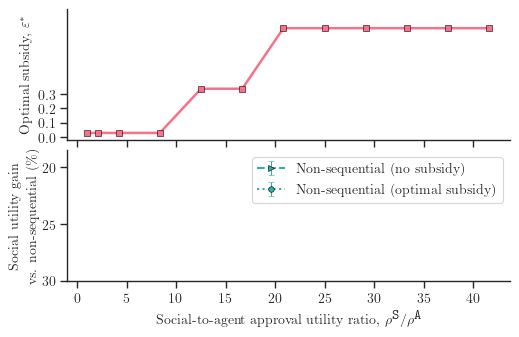

In [3]:
sns.set_theme(context='paper', style='ticks', font_scale=1)
utils.latexify()

width_pt = 750
fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(fig_width, fig_height ),
                                      sharex=True,
                                      gridspec_kw={'hspace': 0.08}
                                      )

palette = sns.color_palette('husl', n_colors=4)

rho_A_val = float(params['rho_A'])
x_ratio = rho_S_range / rho_A_val

# ── Top panel: optimal subsidy ──────────────────────────────────────────────
ax_top.plot(x_ratio, eps_star, 's-', color=palette[0],
            linewidth=1.8, markersize=5, label=r'$\varepsilon^*(\rho_S)$ (MDP)',
            markeredgecolor='black', markeredgewidth=0.4)
ax_top.set_ylabel(r'Optimal subsidy, $\varepsilon^*$', fontsize=10)
ax_top.set_ylim(-0.02, max(eps_star) * 1.15 + 0.02)
ax_top.set_yticks([0, 0.1, 0.2, 0.3])
#Set fontsize for ticklabels to 10
ax_top.tick_params(axis='both', labelsize=10)
#ax_top.legend(fontsize=10, loc='upper left')
sns.despine(ax=ax_top)

# ── Load single-shot baseline ────────────────────────────────────────────────
ss_path = '../../outputs/single_shot_mix/baseline/single_shot_baseline_mix.pt'
ss = torch.load(ss_path, weights_only=False)
assert ss['rho_S_range']      == rho_S_range.tolist()
assert ss['theta_star_range'] == theta_star_range.tolist()

us_ss0_    = np.array(ss['us_true_ss0'])
us_ssopt_  = np.array(ss['us_true_ss_epsopt'])
P_ss0_     = np.array(ss['P_true_ss0'])
A_ss0_     = np.array(ss['A_true_ss0'])
P_ssopt_   = np.array(ss['P_true_ss_epsopt'])
A_ssopt_   = np.array(ss['A_true_ss_epsopt'])
eps_ss_opt = np.array(ss['eps_ss_opt'])

theta_fid = 0.65
j_fid = int(np.argmin(np.abs(theta_star_range - theta_fid)))
assert abs(theta_star_range[j_fid] - theta_fid) < 1e-9, \
    f'theta*=0.65 not in theta_star_range: {theta_star_range.tolist()}'

def _pct_gain(num, den):
    return np.where(np.abs(den) > 1e-12, (num - den) / den * 100.0, np.nan)

pct_a_fid = _pct_gain(us_true[:, j_fid], us_ss0_[:,   j_fid])
pct_b_fid = _pct_gain(us_true[:, j_fid], us_ssopt_[:, j_fid])

# ── Bootstrap 95% CIs on the %-gain, using per-episode MC samples ───────────
# samples_fid_*    : (n_rho, n_ep) from sensitivity_analysis
# samples_ss0_*    : (n_ep,)       from single_shot_baseline (policy rho_S-independent)
# samples_ssopt_*  : (n_rho, n_ep) from single_shot_baseline (policy per rho_S)
_fid_ap = np.asarray(res['samples_fid_approved'])            # (n_rho, n_ep) int8
_fid_co = np.asarray(res['samples_fid_cost']).astype(np.float64)
_ss0_ap = np.asarray(ss['samples_ss0_approved'])             # (n_ep,) int8
_sso_ap = np.asarray(ss['samples_ssopt_approved'])           # (n_rho, n_ep) int8
_sso_co = np.asarray(ss['samples_ssopt_cost']).astype(np.float64)

n_ep_fid = _fid_ap.shape[1]
n_ep_ss  = _ss0_ap.shape[0]
n_rho_   = len(rho_S_range)
B        = 1000          # bootstrap replicates
batch    = 50            # vectorisation batch (controls peak memory)
boot_rng = np.random.default_rng(0)

pct_a_fid_lo = np.full(n_rho_, np.nan)
pct_a_fid_hi = np.full(n_rho_, np.nan)
pct_b_fid_lo = np.full(n_rho_, np.nan)
pct_b_fid_hi = np.full(n_rho_, np.nan)

def _boot_means(samples_1d, B, batch, rng):
    n = len(samples_1d)
    out = np.empty(B)
    for s in range(0, B, batch):
        e = min(s + batch, B)
        idx = rng.integers(0, n, size=(e - s, n))
        out[s:e] = samples_1d[idx].mean(axis=1)
    return out

for i_ in range(n_rho_):
    rho_S_i = rho_S_range[i_]
    eps_fid_i = eps_star[i_]
    eps_sso_i = eps_ss_opt[i_]
    u_true_s  = rho_S_i * _fid_ap[i_].astype(np.float64) - eps_fid_i * _fid_co[i_]
    u_ss0_s   = rho_S_i * _ss0_ap.astype(np.float64)  # eps=0
    u_ssopt_s = rho_S_i * _sso_ap[i_].astype(np.float64) - eps_sso_i * _sso_co[i_]

    m_true  = _boot_means(u_true_s,  B, batch, boot_rng)
    m_ss0   = _boot_means(u_ss0_s,   B, batch, boot_rng)
    m_ssopt = _boot_means(u_ssopt_s, B, batch, boot_rng)

    pct_a_b = np.where(np.abs(m_ss0)   > 1e-12, (m_true - m_ss0)   / m_ss0   * 100.0, np.nan)
    pct_b_b = np.where(np.abs(m_ssopt) > 1e-12, (m_true - m_ssopt) / m_ssopt * 100.0, np.nan)
    pct_a_fid_lo[i_], pct_a_fid_hi[i_] = np.nanquantile(pct_a_b, [0.025, 0.975])
    pct_b_fid_lo[i_], pct_b_fid_hi[i_] = np.nanquantile(pct_b_b, [0.025, 0.975])

yerr_a = np.vstack([pct_a_fid - pct_a_fid_lo, pct_a_fid_hi - pct_a_fid])
yerr_b = np.vstack([pct_b_fid - pct_b_fid_lo, pct_b_fid_hi - pct_b_fid])


# Recover n*(0,0) for diagnostics
c0 = float(params['c0']); c1 = float(params['c1'])

def _recover_n_star(A_row, P_row):
    p = P_row[j_fid]; a = A_row[j_fid]
    if p <= 0:
        return float('nan')
    return (a / p - c0) / c1

n_star_ss0   = np.array([_recover_n_star(A_ss0_[i],   P_ss0_[i])   for i in range(len(rho_S_range))])
n_star_ssopt = np.array([_recover_n_star(A_ssopt_[i], P_ssopt_[i]) for i in range(len(rho_S_range))])

n_max_ss = int(ss['params']['n_max'])
print(f"Single-shot n_max = {n_max_ss}   rho_A = {rho_A_val}")
print(f"{'rho_S':>8}  {'rho_S/rho_A':>12}  {'eps*_fid':>10}  {'eps*_ss':>10}  {'n* (eps=0)':>11}  {'n* (eps=eps*_ss)':>18}")
print('-' * 80)
for i, rho_S in enumerate(rho_S_range):
    print(f"{rho_S:8.1f}  {x_ratio[i]:12.3f}  {eps_star[i]:10.4f}  {eps_ss_opt[i]:10.4f}  "
          f"{n_star_ss0[i]:11.2f}  {n_star_ssopt[i]:18.2f}")

# ── Bottom panel: % utility gain ─────────────────────────────────────────────
ax_bot.errorbar(x_ratio, pct_a_fid, yerr=yerr_a, fmt='>--', color=palette[2],
                linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
                ecolor=palette[2], elinewidth=0.8, capsize=2.5,
                label=r'Non-sequential (no subsidy)')
ax_bot.errorbar(x_ratio, pct_b_fid, yerr=yerr_b, fmt='o:', color=palette[2],
                linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
                ecolor=palette[2], elinewidth=0.8, capsize=2.5,
                label=r'Non-sequential (optimal subsidy)')

ax_bot.set_xlabel(r'Social-to-agent approval utility ratio, $\rho^{\texttt{S}} / \rho^{\texttt{A}}$', fontsize=10)
ax_bot.set_ylabel(
    r'$\begin{array}{c}\textrm{Social utility gain} \\ \textrm{vs. non-sequential}\ (\%)\end{array}$',
    fontsize=10,
    labelpad=12,
    rotation=90,
    va='center'
)
ax_bot.set_ylim(bottom=30)
ax_bot.legend(fontsize=10, loc='best')
sns.despine(ax=ax_bot)

#plt.tight_layout()
plt.show()

fig.subplots_adjust(
    left=0.12,
    right=0.88,   # leave space for colorbar in Code 2
    top=0.95,
    bottom=0.15
)

fig.savefig(os.path.join(figures_dir, 'eps_star_vs_rhoS.pdf'))


In [4]:
width_pt = 1000
fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.65)

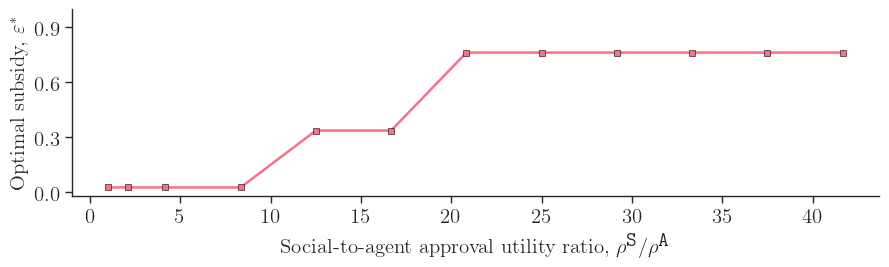

In [7]:
# ── Panel A only: optimal subsidy epsilon* vs rho_S/rho_A ────────────────────
fig_top, ax_top_only = plt.subplots(figsize=(fig_width, fig_height / 2))

ax_top_only.plot(x_ratio, eps_star, 's-', color=palette[0],
                 linewidth=1.8, markersize=5, label=r'$\varepsilon^*(\rho_S)$ (MDP)',
                 markeredgecolor='black', markeredgewidth=0.4)
ax_top_only.set_xlabel(r'Social-to-agent approval utility ratio, $\rho^{\texttt{S}} / \rho^{\texttt{A}}$', fontsize=15)
ax_top_only.set_ylabel(r'Optimal subsidy, $\varepsilon^*$', fontsize=15)
ax_top_only.set_ylim(-0.02, 1)
ax_top_only.set_yticks([0, 0.3, 0.6, 0.9])
ax_top_only.tick_params(axis='both', labelsize=15)
sns.despine(ax=ax_top_only)
fig_top.tight_layout()
plt.show()
fig_top.savefig(os.path.join(figures_dir, 'eps_star_vs_rhoS_top.pdf'), bbox_inches='tight')


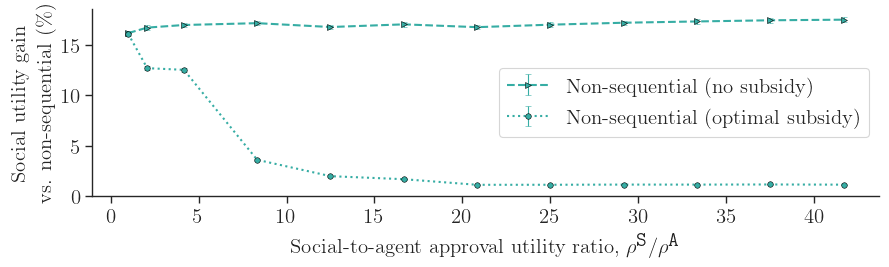

In [8]:
# ── Panel B only: % social utility gain vs non-sequential baseline ──────────
fig_bot, ax_bot_only = plt.subplots(figsize=(fig_width, fig_height / 2))

label_a = r'Non-sequential (no subsidy)' if not np.any(np.isnan(pct_a_fid)) else '_nolegend_'
ax_bot_only.errorbar(x_ratio, pct_a_fid, yerr=yerr_a, fmt='>--', color=palette[2],
                     linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
                     ecolor=palette[2], elinewidth=0.8, capsize=2.5,
                     label=label_a)
ax_bot_only.errorbar(x_ratio, pct_b_fid, yerr=yerr_b, fmt='o:', color=palette[2],
                     linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
                     ecolor=palette[2], elinewidth=0.8, capsize=2.5,
                     label=r'Non-sequential (optimal subsidy)')

ax_bot_only.set_xlabel(r'Social-to-agent approval utility ratio, $\rho^{\texttt{S}} / \rho^{\texttt{A}}$', fontsize=15)
ax_bot_only.set_ylabel(
    r'$\begin{array}{c}\textrm{Social utility gain} \\ \textrm{vs. non-sequential}\ (\%)\end{array}$',
    fontsize=15, labelpad=20, rotation=90, va='center')

#ax_bot_only.set_ylim(bottom=30)
ax_bot_only.set_yticks([0, 5, 10, 15])

ax_bot_only.tick_params(axis='both', labelsize=15)
ax_bot_only.legend(fontsize=15, loc='best')
sns.despine(ax=ax_bot_only)
fig_bot.tight_layout()
plt.show()
fig_bot.savefig(os.path.join(figures_dir, 'pct_gain_vs_rhoS_bot.pdf'), bbox_inches='tight')
